# CSE-CIC-IDS2018 — CTGAN Data Preparation & Augmentation

Optimized to run **locally** (VS Code / Jupyter) — no Google Colab dependencies.

**Pipeline covered here:**
1. Configuration & setup
2. Load `ml_dataset.parquet` (output of notebook 1) and final cleanup
3. Label encoding + stratified train/test split
4. Feature selection via mutual information
5. CTGAN-based augmentation of minority attack classes
6. Merge synthetic + real data into a final balanced training set

> Requires the `ctgan` package: `pip install ctgan`

## 1. Configuration & Setup

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 100)

In [2]:
PROJECT_PATH = Path(r"M:\IDS\c_filesnew")

PROCESSED_DATA_PATH = PROJECT_PATH / "Processed_Data"
RESULTS_PATH        = PROJECT_PATH / "Results"
CTGAN_PATH          = PROJECT_PATH / "CTGAN"
CTGAN_MODELS_PATH   = CTGAN_PATH / "Models"
CTGAN_SYNTHETIC_PATH = CTGAN_PATH / "Synthetic"

for p in [PROCESSED_DATA_PATH, RESULTS_PATH, CTGAN_MODELS_PATH, CTGAN_SYNTHETIC_PATH]:
    p.mkdir(parents=True, exist_ok=True)

ML_DATA = PROCESSED_DATA_PATH / "ml_dataset.parquet"
print("Loading:", ML_DATA)

Loading: M:\IDS\c_filesnew\Processed_Data\ml_dataset.parquet


## 2. Load & Final Cleanup

In [3]:
df = pd.read_parquet(ML_DATA)
print("Shape:", df.shape)
df.head()

Shape: (1002490, 81)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,rn
0,80,6,15/02/2018 09:54:57,6462489,7,4,1365,972,455,0,...,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye,1
1,80,6,15/02/2018 09:30:22,5028081,4,4,391,972,391,0,...,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye,2
2,80,6,15/02/2018 09:53:24,5025621,4,4,440,972,440,0,...,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye,3
3,80,6,15/02/2018 09:54:38,5041225,4,4,301,972,301,0,...,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye,4
4,80,6,15/02/2018 09:53:26,15037164,8,3,714,662,714,0,...,0,0,0,0,0.0,0.0,0,0,DoS attacks-GoldenEye,5


In [4]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("Missing values :", df.isnull().sum().sum())
print("Infinite values:", int(np.isinf(df[numeric_cols]).sum().sum()))
print("Duplicate rows :", df.duplicated().sum())

Missing values : 0
Infinite values: 0
Duplicate rows : 0


In [5]:
# Replace remaining infinities, median-impute, drop Timestamp (not a model feature)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

if "Timestamp" in df.columns:
    df.drop(columns=["Timestamp"], inplace=True)

print("Missing after cleanup :", df.isnull().sum().sum())
print("Shape                 :", df.shape)

Missing after cleanup : 0
Shape                 : (1002490, 80)


## 3. Label Encoding + Train/Test Split

In [6]:
encoder = LabelEncoder()
df["Label"] = encoder.fit_transform(df["Label"])

label_mapping = pd.DataFrame({
    "Class": encoder.classes_,
    "Encoded": encoder.transform(encoder.classes_),
})
label_mapping.to_csv(PROCESSED_DATA_PATH / "label_mapping.csv", index=False)

label_to_id = dict(zip(label_mapping["Class"], label_mapping["Encoded"]))
id_to_label = dict(zip(label_mapping["Encoded"], label_mapping["Class"]))

label_mapping

,Class,Encoded
0,Benign,0
1,Bot,1
2,Brute Force -Web,2
3,Brute Force -XSS,3
4,DDOS attack-HOIC,4
5,DDOS attack-LOIC-UDP,5
6,DDoS attacks-LOIC-HTTP,6
7,DoS attacks-GoldenEye,7
8,DoS attacks-Hulk,8
9,DoS attacks-SlowHTTPTest,9


In [7]:
X = df.drop(columns=["Label"])
y = df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df["Label"] = y_train.values
test_df = X_test.copy();   test_df["Label"] = y_test.values

train_df.to_parquet(PROCESSED_DATA_PATH / "train.parquet", index=False)
test_df.to_parquet(PROCESSED_DATA_PATH / "test.parquet", index=False)

print("Train:", train_df.shape, " Test:", test_df.shape)

Train: (801992, 80)  Test: (200498, 80)


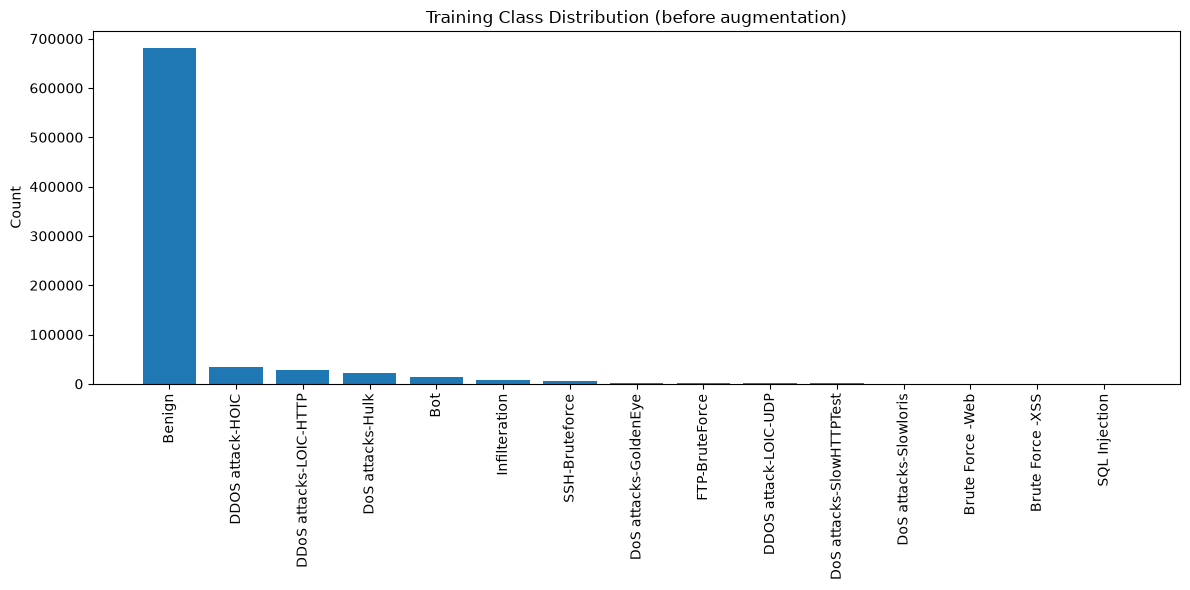

,Class,Count
0,Benign,680805
1,DDOS attack-HOIC,33844
2,DDoS attacks-LOIC-HTTP,29171
3,DoS attacks-Hulk,22017
4,Bot,14293
5,Infilteration,8197
6,SSH-Bruteforce,5940
7,DoS attacks-GoldenEye,2099
8,FTP-BruteForce,1992
9,DDOS attack-LOIC-UDP,1384


In [8]:
dist = (
    train_df["Label"].map(id_to_label).value_counts().reset_index()
)
dist.columns = ["Class", "Count"]

plt.figure(figsize=(12, 6))
plt.bar(dist["Class"], dist["Count"])
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.title("Training Class Distribution (before augmentation)")
plt.tight_layout()
plt.show()

dist

## 4. Feature Selection (Mutual Information)

In [9]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42, n_neighbors=3)

feature_scores = (
    pd.DataFrame({"Feature": X_train.columns, "MI Score": mi_scores})
    .sort_values("MI Score", ascending=False)
    .reset_index(drop=True)
)
feature_scores.to_csv(RESULTS_PATH / "mutual_information_scores.csv", index=False)

feature_scores.head(30)

,Feature,MI Score
0,Init Fwd Win Byts,0.496410
1,Fwd IAT Tot,0.358527
2,Fwd IAT Max,0.357124
3,Dst Port,0.356029
4,rn,0.351486
5,Fwd IAT Mean,0.350000
6,Fwd Header Len,0.339323
7,Flow IAT Max,0.332837
8,Flow Duration,0.318217
9,Fwd Pkts/s,0.311071


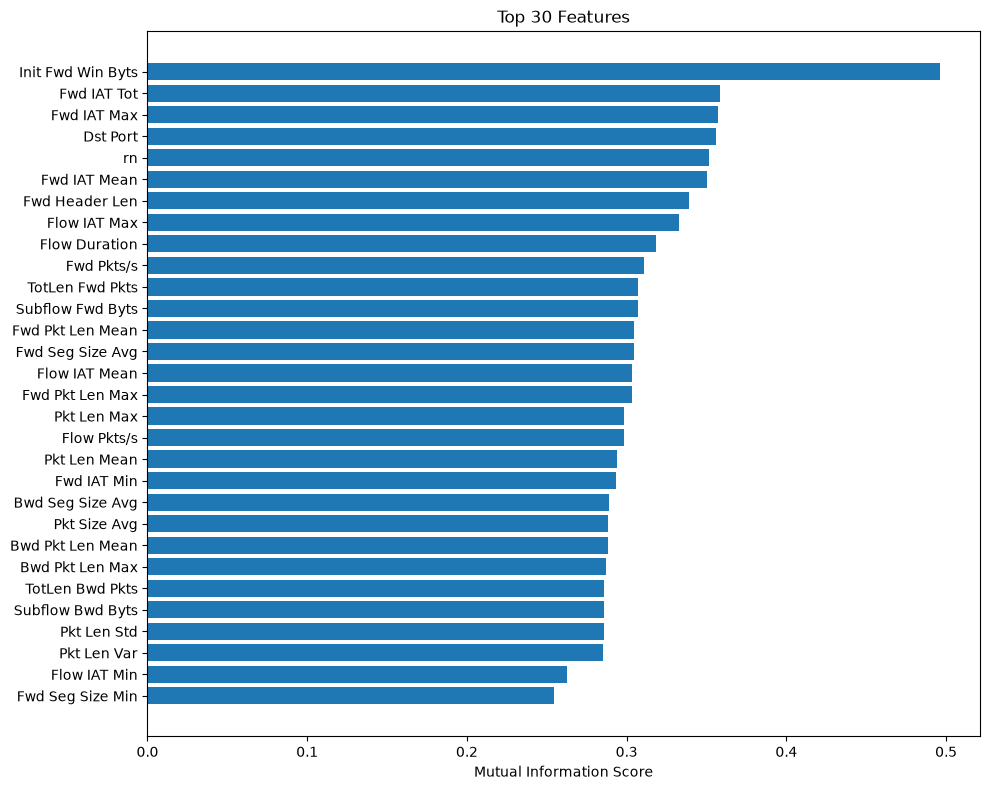

In [10]:
plt.figure(figsize=(10, 8))
top30 = feature_scores.head(30)
plt.barh(top30["Feature"][::-1], top30["MI Score"][::-1])
plt.xlabel("Mutual Information Score")
plt.title("Top 30 Features")
plt.tight_layout()
plt.show()

In [11]:
TOP_K = 30
selected_features = feature_scores.head(TOP_K)["Feature"].tolist()

X_train_selected = X_train[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

train_selected = X_train_selected.copy(); train_selected["Label"] = y_train.values
test_selected = X_test_selected.copy();   test_selected["Label"] = y_test.values

train_selected.to_parquet(PROCESSED_DATA_PATH / "train_selected.parquet", index=False)
test_selected.to_parquet(PROCESSED_DATA_PATH / "test_selected.parquet", index=False)

import pickle
with open(PROCESSED_DATA_PATH / "selected_features.pkl", "wb") as f:
    pickle.dump(selected_features, f)

print("Selected feature sets saved:", train_selected.shape, test_selected.shape)

Selected feature sets saved: (801992, 31) (200498, 31)


## 5. Augmentation of Minority Classes

Not every minority class gets the same treatment, based on how many real samples it actually has:

- **Very rare classes (< `MIN_SAMPLES_FOR_CTGAN` real rows)** — CTGAN cannot learn a reliable joint
  distribution from a few hundred examples across 30 features. Instead we use **bootstrap
  resampling + small Gaussian jitter**: real rows are resampled with replacement and perturbed
  slightly. This can't invent new attack "shapes" the way CTGAN can, but it also can't hallucinate
  an unrealistic distribution — it stays anchored to what's actually real.
- **Better-populated classes (≥ `MIN_SAMPLES_FOR_CTGAN`)** — CTGAN is used, but the amount of
  synthetic data generated is **capped at `MAX_SYNTHETIC_RATIO`× the real count**, rather than
  blindly generating however many rows are needed to hit `target_count`. Forcing CTGAN to
  fabricate, say, 95% of a class from a few hundred real examples produces synthetic data that
  doesn't resemble the real thing (confirmed empirically — see the sanity-check diagnostics in
  Section 6). Capping the ratio means these classes end up **below** their nominal target, but
  the data that does exist is trustworthy.

Net effect: the final training set is **not** perfectly balanced at a uniform ceiling across every
minority class — but every row in it, real or synthetic, is representative of the real attack
pattern it claims to be.

In [12]:
# pip install ctgan   (run once, outside the notebook, if not already installed)
import json as _json
import numpy as np
import torch
from ctgan import CTGAN
import joblib

USE_CUDA = torch.cuda.is_available()
print("CUDA available:", USE_CUDA)
if USE_CUDA:
    print("GPU:", torch.cuda.get_device_name(0))

# --- Thresholds controlling which classes get CTGAN vs. bootstrap+jitter ---
MIN_SAMPLES_FOR_CTGAN = 500   # below this, CTGAN can't reliably learn the distribution
MAX_SYNTHETIC_RATIO = 3       # for CTGAN classes, synthetic rows capped at this multiple of real rows

CUDA available: True
GPU: NVIDIA GeForce RTX 2050


In [13]:
def bootstrap_oversample(class_df, class_label, generate_count, noise_scale=0.02, random_state=42):
    """
    Resample real rows with replacement + small Gaussian jitter (proportional to each
    feature's std). Used for classes with too few real samples for CTGAN to learn a
    meaningful distribution from. This can't create new attack "shapes" the way a generative
    model can, but it also can't drift away from the real distribution the way CTGAN did on
    "Brute Force -Web" (220% mean diff) and similar ultra-rare classes.
    """
    rng = np.random.default_rng(random_state)
    X = class_df.drop(columns=["Label"])

    sampled = X.sample(n=generate_count, replace=True, random_state=random_state).reset_index(drop=True)

    numeric_cols = sampled.select_dtypes(include=np.number).columns
    for col in numeric_cols:
        std = X[col].std()
        if std > 0:
            sampled[col] = sampled[col] + rng.normal(0, std * noise_scale, size=len(sampled))

    non_negative_columns = [c for c in numeric_cols if (X[c] >= 0).all()]
    sampled[non_negative_columns] = sampled[non_negative_columns].clip(lower=0)

    sampled["Label"] = class_label
    return sampled


def augment_class(train_df, class_name, target_count, epochs=500, batch_size=500,
                   pac=10, skew_threshold=1.0,
                   min_samples_for_ctgan=None, max_synthetic_ratio=None):
    """
    Bring a class up toward target_count, choosing the safest method based on how much
    real data actually exists:

    - fewer than `min_samples_for_ctgan` real rows -> bootstrap + jitter (Section 5 markdown
      explains why: CTGAN needs enough real data to learn from, or it hallucinates).
    - otherwise -> CTGAN, but synthetic rows are capped at `max_synthetic_ratio` x the real
      count, so a class isn't forced to be 90%+ fabricated just to hit target_count.
    """
    min_samples_for_ctgan = MIN_SAMPLES_FOR_CTGAN if min_samples_for_ctgan is None else min_samples_for_ctgan
    max_synthetic_ratio = MAX_SYNTHETIC_RATIO if max_synthetic_ratio is None else max_synthetic_ratio

    class_label = label_to_id[class_name] if isinstance(class_name, str) else class_name
    safe_name = str(class_name).replace("/", "_").replace(" ", "_")

    class_df = train_df[train_df["Label"] == class_label].copy()
    current_count = len(class_df)

    if current_count == 0:
        print(f"[{class_name}] no real samples found, skipping.")
        return None

    # --- Path A: too few real samples for CTGAN -> bootstrap + jitter, straight to target_count ---
    if current_count < min_samples_for_ctgan:
        generate_count = target_count - current_count
        print(f"[{class_name}] current={current_count} (< {min_samples_for_ctgan}) "
              f"-> using bootstrap+jitter, to_generate={max(generate_count, 0)}")

        if generate_count <= 0:
            print("  -> already at/above target, skipping.")
            return None

        synthetic = bootstrap_oversample(class_df, class_label, generate_count)
        synthetic.to_parquet(CTGAN_SYNTHETIC_PATH / f"{safe_name}.parquet", index=False)
        print("  -> done (bootstrap+jitter).")
        return synthetic

    # --- Path B: enough real samples -> CTGAN, but cap the synthetic:real ratio ---
    effective_target = min(target_count, current_count * (1 + max_synthetic_ratio))
    generate_count = effective_target - current_count

    print(f"[{class_name}] current={current_count}  target={target_count}  "
          f"ratio-capped effective_target={effective_target}  to_generate={generate_count}")

    if generate_count <= 0:
        print("  -> already at/above effective target, skipping.")
        return None

    X = class_df.drop(columns=["Label"])
    discrete_columns = [c for c in ("Dst Port", "Protocol") if c in X.columns]
    continuous_columns = [c for c in X.columns if c not in discrete_columns]

    skewed_columns = [
        c for c in continuous_columns
        if (X[c] >= 0).all() and X[c].skew() > skew_threshold
    ]
    non_negative_columns = [c for c in continuous_columns if (X[c] >= 0).all()]

    X_transformed = X.copy()
    for col in skewed_columns:
        X_transformed[col] = np.log1p(X_transformed[col])

    if batch_size % pac != 0:
        adjusted = max(pac, (batch_size // pac) * pac)
        print(f"  Adjusted batch_size {batch_size} -> {adjusted} (must be divisible by pac={pac})")
        batch_size = adjusted

    ctgan = CTGAN(epochs=epochs, batch_size=batch_size, pac=pac, verbose=True, cuda=USE_CUDA)
    ctgan.fit(X_transformed, discrete_columns=discrete_columns)

    joblib.dump(ctgan, CTGAN_MODELS_PATH / f"{safe_name}_ctgan.pkl")
    with open(CTGAN_MODELS_PATH / f"{safe_name}_log_columns.json", "w") as f:
        _json.dump(skewed_columns, f)

    synthetic = ctgan.sample(generate_count)

    for col in skewed_columns:
        synthetic[col] = np.expm1(synthetic[col])

    synthetic[non_negative_columns] = synthetic[non_negative_columns].clip(lower=0)
    synthetic["Label"] = class_label

    synthetic.to_parquet(CTGAN_SYNTHETIC_PATH / f"{safe_name}.parquet", index=False)
    print("  -> done (CTGAN, ratio-capped).")

    return synthetic

In [14]:
train_selected = pd.read_parquet(PROCESSED_DATA_PATH / "train_selected.parquet")
train_selected["Label"].value_counts().sort_index()

Label
0     680805
1      14293
2        489
3        184
4      33844
5       1384
6      29171
7       2099
8      22017
9        986
10       521
11      1992
12      8197
13        70
14      5940
Name: count, dtype: int64

### Downsample the Majority Class (Benign) — Training Set Only

`Benign` alone makes up roughly 79% of the training set (680,805 of ~858,000 rows) — far more
dominant than any single attack type. This is left completely untouched in `test_selected`
(the test set must stay representative of real-world proportions for evaluation to mean
anything), but for **training**, this level of dominance can bias the model toward always
predicting Benign and drown out the gradient signal from attack classes.

We cap `Benign` at 100,000 rows via random undersampling. The other large classes
(`DDOS attack-HOIC` ~33.8k, `DDoS attacks-LOIC-HTTP` ~29k, `DoS attacks-Hulk` ~22k) are left as-is
— they're an order of magnitude smaller than Benign already, and capping them too wasn't judged
necessary.

In [15]:
BENIGN_CLASS_NAME = "Benign"
BENIGN_CAP = 100_000

benign_id = label_to_id[BENIGN_CLASS_NAME]
benign_mask = train_selected["Label"] == benign_id
current_benign = int(benign_mask.sum())

if current_benign > BENIGN_CAP:
    benign_rows = train_selected[benign_mask].sample(n=BENIGN_CAP, random_state=42)
    other_rows = train_selected[~benign_mask]
    train_selected = pd.concat([other_rows, benign_rows], ignore_index=True)
    print(f"Downsampled {BENIGN_CLASS_NAME}: {current_benign:,} -> {BENIGN_CAP:,}")
else:
    print(f"{BENIGN_CLASS_NAME} count ({current_benign:,}) already <= cap ({BENIGN_CAP:,}), no change made.")

train_selected["Label"].map(id_to_label).value_counts()

Downsampled Benign: 680,805 -> 100,000


Label
Benign                      100000
DDOS attack-HOIC             33844
DDoS attacks-LOIC-HTTP       29171
DoS attacks-Hulk             22017
Bot                          14293
Infilteration                 8197
SSH-Bruteforce                5940
DoS attacks-GoldenEye         2099
FTP-BruteForce                1992
DDOS attack-LOIC-UDP          1384
DoS attacks-SlowHTTPTest       986
DoS attacks-Slowloris          521
Brute Force -Web               489
Brute Force -XSS               184
SQL Injection                   70
Name: count, dtype: int64

**Grouping note:** SQL Injection is excluded entirely (real count = 70, far below any
reasonable threshold for either method) — every real SQL Injection row already present in
`train_selected` still flows into `balanced_train_selected` untouched, so the model still sees
and learns from the real (if few) examples that exist.

For everything else below, `augment_class` automatically picks bootstrap+jitter or ratio-capped
CTGAN per class based on the real counts you found:

| Class | Real Count | Method Used |
|---|---|---|
| Brute Force -XSS | 184 | Bootstrap + jitter |
| Brute Force -Web | 489 | Bootstrap + jitter |
| DoS attacks-Slowloris | 521 | CTGAN, ratio-capped |
| DoS attacks-SlowHTTPTest | 986 | CTGAN, ratio-capped |
| DDOS attack-LOIC-UDP | 1,384 | CTGAN, ratio-capped |
| DoS attacks-GoldenEye | 2,099 | CTGAN, ratio-capped |
| Infilteration | 8,197 | CTGAN, ratio-capped (well under the cap already) |
| Bot | 14,293 | Skipped — already above target |

> None of these classes will necessarily reach exactly 10,000 rows anymore — that's expected and
> intentional. Check the printed `effective_target` for each class after running the cell below.

In [16]:
TARGET_COUNTS = {
    "Bot": 10_000,
    "Infilteration": 10_000,
    "DoS attacks-Slowloris": 10_000,
    "DoS attacks-SlowHTTPTest": 10_000,
    "DoS attacks-GoldenEye": 10_000,
    "DDOS attack-LOIC-UDP": 10_000,
    "Brute Force -Web": 10_000,
    "Brute Force -XSS": 10_000,
}

for class_name, target in TARGET_COUNTS.items():
    augment_class(train_selected, class_name, target)

[Bot] current=14293  target=10000  ratio-capped effective_target=10000  to_generate=-4293
  -> already at/above effective target, skipping.
[Infilteration] current=8197  target=10000  ratio-capped effective_target=10000  to_generate=1803


Gen. (-01.22) | Discrim. (-01.01): 100%|██████████| 500/500 [26:48<00:00,  3.22s/it]


  -> done (CTGAN, ratio-capped).
[DoS attacks-Slowloris] current=521  target=10000  ratio-capped effective_target=2084  to_generate=1563


Gen. (-00.04) | Discrim. (-01.42): 100%|██████████| 500/500 [01:26<00:00,  5.77it/s]


  -> done (CTGAN, ratio-capped).
[DoS attacks-SlowHTTPTest] current=986  target=10000  ratio-capped effective_target=3944  to_generate=2958


...

  -> done (CTGAN, ratio-capped).
[DoS attacks-GoldenEye] current=2099  target=10000  ratio-capped effective_target=8396  to_generate=6297


Gen. (-00.90) | Discrim. (-00.17): 100%|██████████| 500/500 [05:17<00:00,  1.58it/s]


  -> done (CTGAN, ratio-capped).
[DDOS attack-LOIC-UDP] current=1384  target=10000  ratio-capped effective_target=5536  to_generate=4152


Gen. (-01.02) | Discrim. (+00.17): 100%|██████████| 500/500 [01:04<00:00,  7.80it/s]


  -> done (CTGAN, ratio-capped).
[Brute Force -Web] current=489 (< 500) -> using bootstrap+jitter, to_generate=9511
  -> done (bootstrap+jitter).
[Brute Force -XSS] current=184 (< 500) -> using bootstrap+jitter, to_generate=9816
  -> done (bootstrap+jitter).


## 6. Sanity Check: Real vs. Synthetic (one class)

In [17]:
# Map sanitized filenames (spaces/slashes replaced with "_") back to the original class names,
# since augment_class() sanitizes class_name when writing the synthetic file.
safe_name_to_class = {
    str(cls).replace("/", "_").replace(" ", "_"): cls
    for cls in label_to_id.keys()
}

synthetic_class_files = {f.stem: f for f in CTGAN_SYNTHETIC_PATH.glob("*.parquet")}

if not synthetic_class_files:
    print("No synthetic files found -- every class may already be at/above its target.")
else:
    safe_name = next(iter(synthetic_class_files))       # or pick a specific one explicitly
    check_class = safe_name_to_class.get(safe_name, safe_name)
    print("Sanity-checking class:", check_class)

    synthetic_check = pd.read_parquet(synthetic_class_files[safe_name])

    real_subset = train_selected[
        train_selected["Label"] == label_to_id[check_class]
    ].drop(columns=["Label"])
    synthetic_subset = synthetic_check.drop(columns=["Label"])

    comparison_diag = pd.DataFrame({
        "Real Mean": real_subset.mean(),
        "Synthetic Mean": synthetic_subset.mean(),
        "Real Std": real_subset.std(),
        "Synthetic Std": synthetic_subset.std(),
    })
    comparison_diag["Mean Diff %"] = (
        (comparison_diag["Real Mean"] - comparison_diag["Synthetic Mean"]).abs()
        / (comparison_diag["Real Mean"].abs() + 1e-8) * 100
    )
    comparison_diag["Std Diff %"] = (
        (comparison_diag["Real Std"] - comparison_diag["Synthetic Std"]).abs()
        / (comparison_diag["Real Std"].abs() + 1e-8) * 100
    )
    comparison_diag = comparison_diag.round(2)
    comparison_diag.to_csv(RESULTS_PATH / f"{check_class}_ctgan_comparison.csv")

    print("Avg Mean Diff %:", comparison_diag["Mean Diff %"].mean().round(2))
    print("Avg Std Diff % :", comparison_diag["Std Diff %"].mean().round(2))
    comparison_diag.sort_values("Mean Diff %", ascending=False).head(15)

Sanity-checking class: Brute Force -Web
Avg Mean Diff %: 1.46
Avg Std Diff % : 0.98


In [18]:
# Separate near-zero-mean features (can inflate % diffs) from substantive ones
NEAR_ZERO_THRESHOLD = 1.0

near_zero = comparison_diag[comparison_diag["Real Mean"].abs() < NEAR_ZERO_THRESHOLD]
substantive = comparison_diag[comparison_diag["Real Mean"].abs() >= NEAR_ZERO_THRESHOLD]

print(f"Near-zero features   ({len(near_zero)}): avg Mean Diff % = {near_zero['Mean Diff %'].mean():.2f}")
print(f"Substantive features ({len(substantive)}): avg Mean Diff % = {substantive['Mean Diff %'].mean():.2f}")

substantive.sort_values("Mean Diff %", ascending=False)

Near-zero features   (0): avg Mean Diff % = nan
Substantive features (30): avg Mean Diff % = 1.46


,Real Mean,Synthetic Mean,Real Std,Synthetic Std,Mean Diff %,Std Diff %
Flow IAT Min,2438938.00,2558925.34,9399554.23,9568469.47,4.92,1.80
Fwd IAT Min,2439084.45,2555657.61,9399516.15,9563398.85,4.78,1.74
Flow Pkts/s,14538.95,15026.34,39708.51,40343.25,3.35,1.60
Fwd Pkts/s,14532.10,15013.71,39710.66,40339.92,3.31,1.58
Fwd Header Len,693.68,675.29,1225.23,1210.18,2.65,1.23
Dst Port,229.17,223.55,1441.26,1385.93,2.45,3.84
TotLen Fwd Pkts,12339.17,12041.54,21976.77,21670.01,2.41,1.40
Subflow Fwd Byts,12339.17,12048.26,21976.77,21661.04,2.36,1.44
Subflow Bwd Byts,15469.11,15162.21,29473.47,29034.78,1.98,1.49
TotLen Bwd Pkts,15469.11,15163.10,29473.47,29031.44,1.98,1.50


## 7. Merge Synthetic Data → Final Balanced Training Set

In [19]:
synthetic_files = sorted(CTGAN_SYNTHETIC_PATH.glob("*.parquet"))
synthetic_df = pd.concat([pd.read_parquet(f) for f in synthetic_files], ignore_index=True)

print("Synthetic rows:", synthetic_df.shape)
synthetic_df["Label"].map(id_to_label).value_counts()

Synthetic rows: (36100, 31)


Label
Brute Force -XSS            9816
Brute Force -Web            9511
DoS attacks-GoldenEye       6297
DDOS attack-LOIC-UDP        4152
DoS attacks-SlowHTTPTest    2958
Infilteration               1803
DoS attacks-Slowloris       1563
Name: count, dtype: int64

In [20]:
balanced_train = pd.concat([train_selected, synthetic_df], ignore_index=True)

balanced_train.to_parquet(
    PROCESSED_DATA_PATH / "balanced_train_selected.parquet", index=False
)

print("Balanced training set:", balanced_train.shape)
balanced_train["Label"].map(id_to_label).value_counts()

Balanced training set: (257287, 31)


Label
Benign                      100000
DDOS attack-HOIC             33844
DDoS attacks-LOIC-HTTP       29171
DoS attacks-Hulk             22017
Bot                          14293
Infilteration                10000
Brute Force -XSS             10000
Brute Force -Web             10000
DoS attacks-GoldenEye         8396
SSH-Bruteforce                5940
DDOS attack-LOIC-UDP          5536
DoS attacks-SlowHTTPTest      3944
DoS attacks-Slowloris         2084
FTP-BruteForce                1992
SQL Injection                   70
Name: count, dtype: int64

---
**Outputs produced by this notebook (under `Processed_Data/`):**
- `train.parquet` / `test.parquet` — full-feature split
- `train_selected.parquet` / `test_selected.parquet` — top-30-feature split
- `label_mapping.csv`, `selected_features.pkl`
- `balanced_train_selected.parquet` — final CTGAN-augmented, class-balanced training set

This `balanced_train_selected.parquet` (together with `test_selected.parquet` for evaluation)
is what should be fed into model training.